# RaCo Simple Keypoint Extraction Demo

First load the image and a RaCo extractor:

In [1]:
import torch

from raco import RaCo
from raco.utils import load_image

device = "cuda" if torch.cuda.is_available() else "cpu"
image = load_image("assets/i_castle.png").to(device)

# Initialize a RaCo extractor with the default configuration
extractor = RaCo().to(device)

[RaCo] Loaded weights from https://github.com/cvg/RaCo/releases/download/v1.0.0/raco.pth


In [2]:
output = extractor.extract(image)
print("Output keys:", [k for k in output])

Output keys: ['keypoints', 'keypoint_scores', 'ranker_scores', 'covariances', 'image_size']


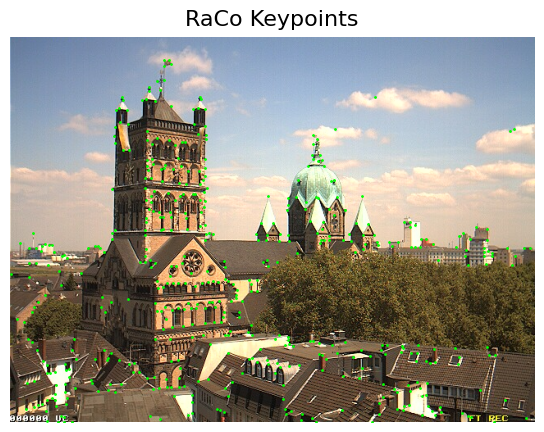

In [3]:
import matplotlib.pyplot as plt

from raco import utils, viz2d

output = utils.batch_to_device(output, "cpu")

ax = viz2d.plot_images([image])
viz2d.plot_keypoints([output["keypoints"][0]], axes=ax)

plt.suptitle("RaCo Keypoints", fontsize=16, y=0.95)
plt.tight_layout()

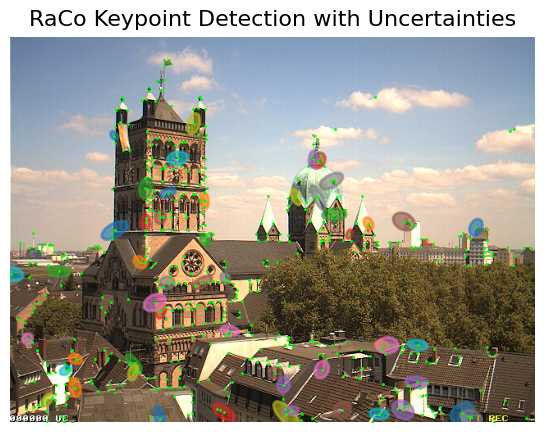

In [4]:
ax = viz2d.plot_images([image])

# Subsample keypoints for cleaner visualization
subsample = 10
idxs = torch.randperm(
    len(output["keypoints"][0]), generator=torch.Generator().manual_seed(42)
)[::subsample]

keypoints = output["keypoints"][0]
subsampled_keypoints = output["keypoints"][0][idxs]
subsampled_covariances = output["covariances"][0][idxs]

viz2d.plot_covariance_ellipses(
    [subsampled_keypoints],
    [subsampled_covariances],
    axes=ax,
    sigma=20,
)

viz2d.plot_keypoints(
    [keypoints],
    axes=ax,
)

plt.suptitle("RaCo Keypoint Detection with Uncertainties", fontsize=16, y=0.95)
plt.tight_layout()

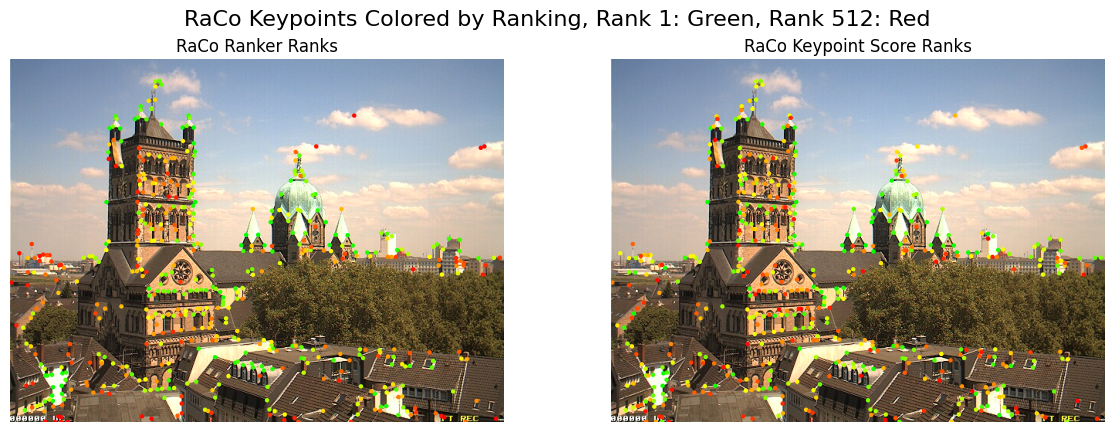

In [5]:
from raco.utils import rank_from_scores

ax = viz2d.plot_images([image] * 2)

ranker_integer_ranks = rank_from_scores(output["ranker_scores"][0])
ranker_colors = viz2d.cm_GnRd(
    (ranker_integer_ranks - 1) / (len(ranker_integer_ranks) - 1)
)  # Normalize to [0, 1]

keypoint_score_integer_ranks = rank_from_scores(output["keypoint_scores"][0])
colors_keypoint_scores = viz2d.cm_GnRd(
    (keypoint_score_integer_ranks - 1) / (len(keypoint_score_integer_ranks) - 1)
)  # Normalize to [0, 1]

viz2d.plot_keypoints(
    [output["keypoints"][0]] * 2,
    axes=ax,
    colors=[ranker_colors, colors_keypoint_scores],
    ps=10,
)

plt.suptitle(
    "RaCo Keypoints Colored by Ranking, "
    f"Rank 1: Green, Rank {len(ranker_integer_ranks)}: Red",
    fontsize=16,
    y=0.95,
)
ax[0].set_title("RaCo Ranker Ranks")
ax[1].set_title("RaCo Keypoint Score Ranks")
plt.tight_layout()

# Loading RaCo extractor from PyTorch Hub

In [6]:
raco_hub = torch.hub.load("cvg/RaCo", "raco", pretrained=True).to(device)
output_hub = raco_hub.extract(image)
print("Output keys from hub model:", [k for k in output_hub])

Using cache found in /home/abhiram/.cache/torch/hub/cvg_RaCo_main


[RaCo] Loaded weights from https://github.com/cvg/RaCo/releases/download/v1.0.0/raco.pth
Output keys from hub model: ['keypoints', 'keypoint_scores', 'ranker_scores', 'covariances', 'image_size']
